# Tutorial 2: Handling Neural Data in Time

Welcome to the second tutorial! In Tutorial 1, we estimated Mutual Information (MI) between independent, tabular rows of data. But real neural data isn't tabular—it evolves over time.

If you record Local Field Potentials ($X$) and Motor Kinematics ($Y$), a naive approach would be to calculate the MI between single, instantaneous timepoints: $I(X_i ; Y_i)$. However, a single voltage value carries almost zero information. The brain encodes information in trajectories, rates, and patterns. To capture this, we must look at a **window of time**.

This tutorial is a **visual guide** to how `NeuralMI` processes time-series data. The goal is to build a strong intuition for what the library is doing under the hood before we feed this data into a deep neural network.

In [2]:
import numpy as np
import torch
import neural_mi as nmi
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("talk")

## 1. The Problem

To capture temporal patterns, we need to extract windows of data. 

**Traditionally:** We can use a "sliding window." Extract a 100ms window, shift by 1ms, and extract another. If you have 10 minutes of high-frequency data, creating all these overlapping 3D tensors will create a massive array, likely crashing your GPU with an Out-Of-Memory (OOM) error if loaded as one chunk -as often needed for the estimator-.

**Our Solution (Dynamic Jittering):** 
`NeuralMI` does it differently:
1. **Zero Overlap:** The library chops your data into strictly *non-overlapping* blocks. This keeps memory usage incredibly tiny.
2. **Dynamic Jittering:** To prevent the neural network from memorizing arbitrary block boundaries, the `Trainer` randomly shifts the starting point of these blocks at the beginning of every training epoch. 

For example, over 50 epochs, the network sees every possible overlapping slice of data, learning shift-invariant features without ever blowing up your RAM.

## 2. Continuous Data (LFP, EEG, Kinematics)

Let's see this chunking in action. **Crucially, NeuralMI expects continuous data to have the shape `(n_timepoints, n_channels)`.** Time is always the first dimension.

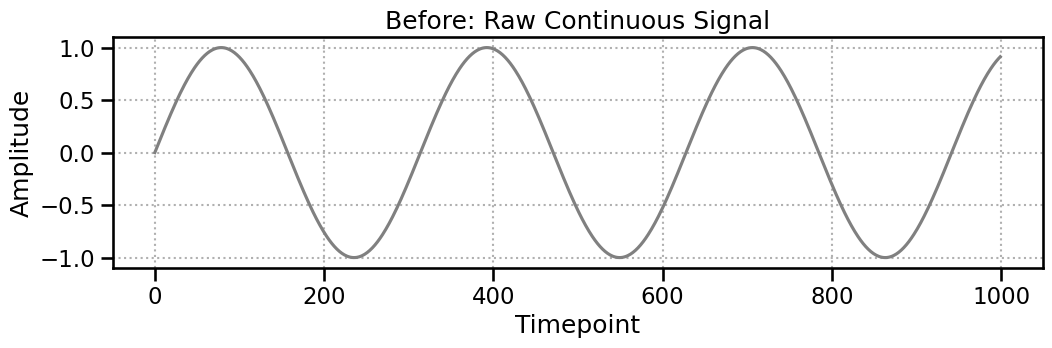

Raw data shape: (1000, 1) (timepoints, channels)


In [3]:
# Generate 1000 timepoints, 1 channel
raw_continuous_data = np.sin(np.linspace(0, 20, 1000)).reshape(1000, 1)

plt.figure(figsize=(12, 3))
plt.plot(raw_continuous_data, color='gray')
plt.title("Before: Raw Continuous Signal")
plt.xlabel("Timepoint")
plt.ylabel("Amplitude")
plt.grid(True, linestyle=':')
plt.show()

print(f"Raw data shape: {raw_continuous_data.shape} (timepoints, channels)")

### Processing Continuous Data
We never instantiate processors directly. We pass our raw data into the `nmi.data.handler.create_dataset` factory. 

Let's use a `window_size` of 100 timepoints. Since there is no overlap, 1000 total timepoints / 100 timepoints per window = exactly **10 samples**.

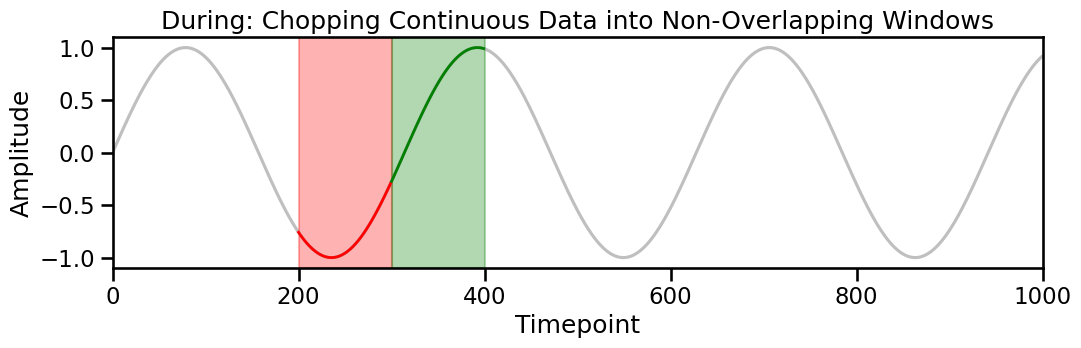

In [5]:
# --- CONTINUOUS "DURING" PLOT ---
sample_idx_to_show = 2
window_size = 100

plt.figure(figsize=(12, 3))
plt.plot(raw_continuous_data, color='gray', alpha=0.5)

for i in range(10): 
    start = i * window_size
    end = (i + 1) * window_size
    # Highlight the specific window we are going to look at
    if i == sample_idx_to_show:
        color = 'red'
        alpha = 0.3
        plt.plot(np.arange(start, end), raw_continuous_data[start:end], color='red', linewidth=2)
        plt.axvspan(start, end, color=color, alpha=alpha)

    elif i == sample_idx_to_show + 1:
        color = 'green'
        alpha = 0.3
        plt.plot(np.arange(start, end), raw_continuous_data[start:end], color='green', linewidth=2)
        plt.axvspan(start, end, color=color, alpha=alpha)
    else:
        color = '#e0e0e0' if i % 2 == 0 else '#ffffff'
        alpha = 0.5

plt.title("During: Chopping Continuous Data into Non-Overlapping Windows")
plt.xlabel("Timepoint")
plt.ylabel("Amplitude")
plt.xlim(0, 1000)
plt.show()

2026-02-24 12:35:03 - neural_mi - INFO - Window coverage: 10/10 windows have sufficient data
2026-02-24 12:35:03 - neural_mi - INFO - Created 10 aligned windows
Processed data shape: torch.Size([10, 1, 101]) (windows, channels, timepoints_per_window)


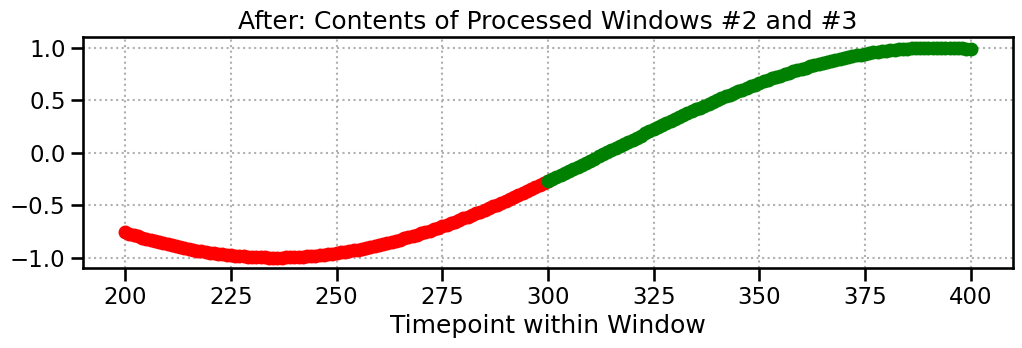

In [42]:
dataset = nmi.data.handler.create_dataset(
    x_data=raw_continuous_data,
    processor_type_x='continuous',
    processor_params_x={'window_size': window_size}
)

processed_data = dataset.x_data.to('cpu')  # Shape: (n_samples, n_channels, n_features)

print(f"Processed data shape: {processed_data.shape} (windows, channels, timepoints_per_window)")

plt.figure(figsize=(12, 3))
plt.plot(np.arange(sample_idx_to_show*window_size, (sample_idx_to_show+1)*window_size +1), processed_data[sample_idx_to_show, 0, :].numpy(), 'o-', color='red')
plt.plot(np.arange((sample_idx_to_show+1)*window_size, (sample_idx_to_show+2)*window_size +1), processed_data[sample_idx_to_show+1, 0, :].numpy(), 'o-', color='green')
plt.title(f"After: Contents of Processed Windows #{sample_idx_to_show} and #{sample_idx_to_show+1}")
plt.xlabel("Timepoint within Window")
plt.grid(True, linestyle=':')
plt.show()

## 3. Spike Data (Neuronal Firing)

Spike data is fundamentally different. It's a list of discrete event times, not a continuous matrix. The library must convert this irregular format into a regular 3D tensor that neural networks can ingest.

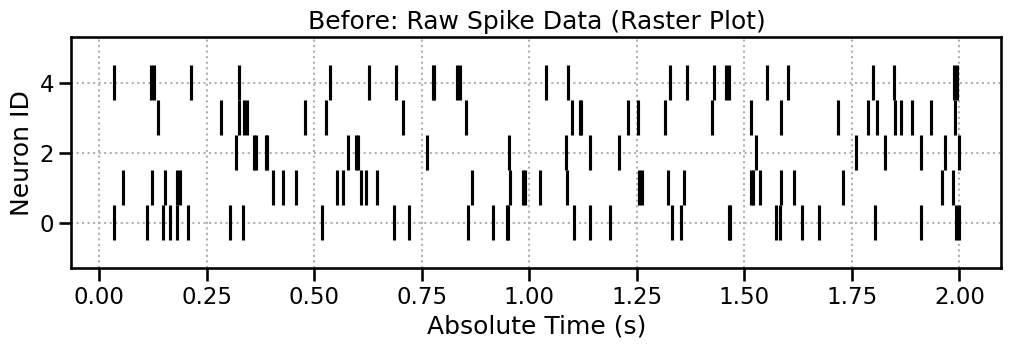

In [15]:
# Generate 5 neurons firing over 2.0 seconds
spike_data, _ = nmi.generators.generate_correlated_spike_trains(
    n_neurons=5, duration=2.0, firing_rate=15
)

plt.figure(figsize=(12, 3))
plt.eventplot(spike_data, color='black')
plt.title("Before: Raw Spike Data (Raster Plot)")
plt.xlabel("Absolute Time (s)")
plt.ylabel("Neuron ID")
plt.grid(True, linestyle=':')
plt.show()

### Processing Spike Data
This is a critical architectural feature of NeuralMI. The final tensor does **not** contain the absolute spike times (like 1.84 seconds). Instead:
1.  **Relative Times**: Spike times are measured relative to the *start* of the window. This makes the neural network shift-invariant.
2.  **Padding with Zeros**: Because each window can have a different number of spikes, the array is padded with zeros up to a fixed sequence length (`max_spikes_per_window`). Zeros act as a null character.

Let's process the data with a window size of 0.5 seconds.

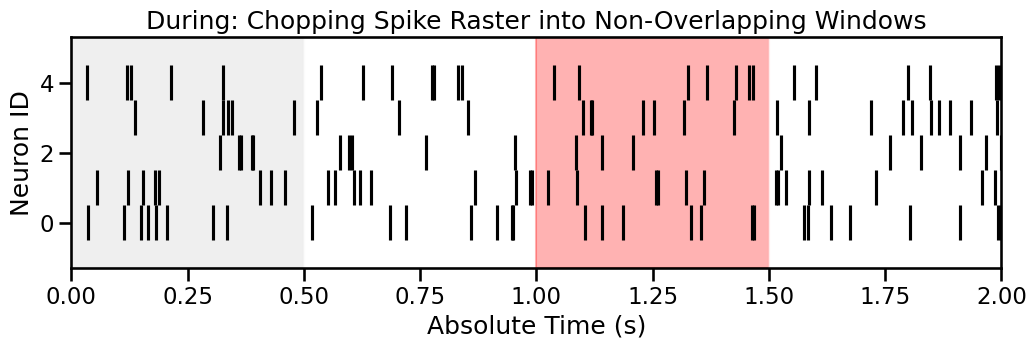

In [45]:
window_size_s = 0.5 

# --- SPIKE "DURING" PLOT ---
plt.figure(figsize=(12, 3))
plt.eventplot(spike_data, color='black')

for i in range(4): 
    start = i * window_size_s
    end = (i + 1) * window_size_s
    color = 'red' if i == sample_idx_to_show else ('#e0e0e0' if i % 2 == 0 else '#ffffff')
    alpha = 0.3 if i == sample_idx_to_show else 0.5
    plt.axvspan(start, end, color=color, alpha=alpha)

plt.title("During: Chopping Spike Raster into Non-Overlapping Windows")
plt.xlabel("Absolute Time (s)")
plt.ylabel("Neuron ID")
plt.xlim(0, 2.0)
plt.show()

In [ ]:
dataset = nmi.data.handler.create_dataset(
    x_data=spike_data,
    processor_type_x='spike',
    processor_params_x={'window_size': window_size_s}
)

processed_spike_data = dataset.x_data.to('cpu')  # Shape: (n_windows, n_neurons, max_spikes_per_window)
sample_idx_to_show = 1 # The second window (0.5s to 1.0s)

print("--- Theoretical vs. Actual ---")
print("Total duration: 2.0s | Window size: 0.5s -> 4 non-overlapping windows.")
print(f"Processed Tensor Shape: {processed_spike_data.shape} (windows, neurons, max_spikes)")
print("\n--- Contents of Window #1 (0.5s to 1.0s) ---")
print("Notice: Times are relative to window start, and missing spikes are padded with 0.0")
for i in range(len(spike_data)):
    content = processed_spike_data[sample_idx_to_show, i, :].numpy()
    print(f"  Neuron {i}: {np.round(content, 3)}")

2026-02-24 12:22:38 - neural_mi - INFO - Window coverage: 4/4 windows have sufficient data
2026-02-24 12:22:38 - neural_mi - INFO - Created 4 aligned windows
--- Theoretical vs. Actual ---
Total duration: 2.0s | Window size: 0.5s -> 4 non-overlapping windows.
Processed Tensor Shape: torch.Size([4, 5, 11]) (windows, neurons, max_spikes)

--- Contents of Window #1 (0.5s to 1.0s) ---
Notice: Times are relative to window start, and missing spikes are padded with 0.0
  Neuron 0: [0.152 0.186 0.325 0.381 0.414 0.416 0.    0.    0.    0.    0.   ]
  Neuron 1: [0.019 0.034 0.074 0.087 0.112 0.334 0.422 0.452 0.457 0.492 0.   ]
  Neuron 2: [0.044 0.063 0.069 0.229 0.419 0.    0.    0.    0.    0.    0.   ]
  Neuron 3: [0.172 0.318 0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
  Neuron 4: [0.003 0.093 0.156 0.242 0.246 0.298 0.305 0.    0.    0.    0.   ]


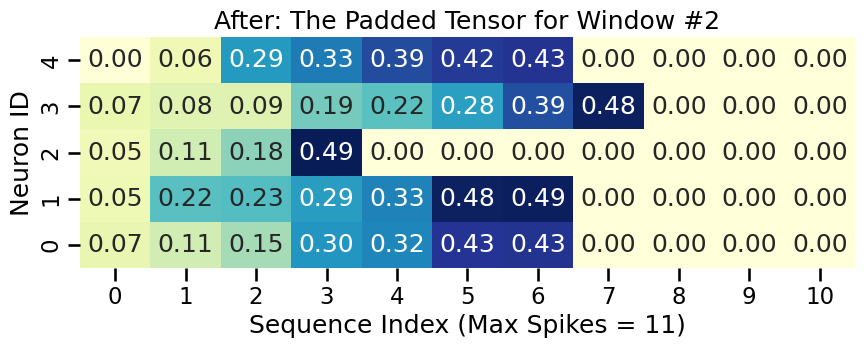

In [ ]:
# Extract the single window tensor (Neurons x Max Spikes)
window_tensor = processed_spike_data[sample_idx_to_show].numpy() 

fig, ax = plt.subplots(figsize=(10, 3))
# Use a heatmap to clearly show the relative times and the zero-padding
sns.heatmap(window_tensor, annot=True, fmt=".2f", cmap="YlGnBu", cbar=False, ax=ax)
ax.set_title(f"After: The Padded Tensor for Window #{sample_idx_to_show}")
ax.set_xlabel("Sequence Index (Max Spikes = 11)")
ax.set_ylabel("Neuron ID")
ax.invert_yaxis() 
plt.show()

## 4. Categorical Data (Behavioral States, Stimuli)

Categorical data represents discrete states (e.g., 0=resting, 1=running, 2=grooming). The library handles this by chunking the states and then **one-hot encoding** them.

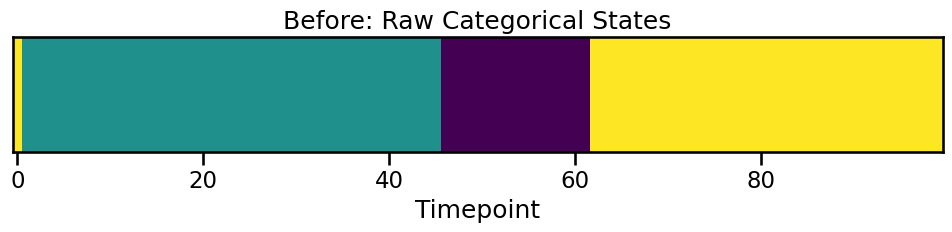

In [21]:
# Generate 100 timepoints, 1 channel, 3 categories (0, 1, 2)
raw_cat_data, _ = nmi.generators.generate_correlated_categorical_series(
    n_samples=100, n_channels=1, n_categories=3, use_torch=False
)

fig, ax = plt.subplots(figsize=(12, 1.5))
ax.imshow(raw_cat_data.T, aspect='auto', cmap='viridis', interpolation='nearest')
ax.set_title("Before: Raw Categorical States")
ax.set_xlabel("Timepoint")
ax.set_yticks([])
plt.show()


### Processing Categorical Data
If we use a window size of 5 timepoints, the processor converts each integer state into a one-hot vector (e.g., `2` becomes `[0, 0, 1]`), and flattens them into a single feature vector.

In [25]:
dataset = nmi.data.handler.create_dataset(
    x_data=raw_cat_data,
    processor_type_x='categorical',
    processor_params_x={'window_size': 5}
)

processed_cat_data = dataset.x_data.to('cpu')  # Shape: (n_windows, n_channels, window_size * n_categories)

print(f"Raw states for Window #0: {raw_cat_data[:5, 0]}")
print(f"Processed one-hot vector: {processed_cat_data[0, 0, :].numpy()}")
print(f"\nFinal processed shape: {processed_cat_data.shape} (windows, channels, window_size * n_categories)")

2026-02-24 12:28:23 - neural_mi - INFO - Window coverage: 20/20 windows have sufficient data
2026-02-24 12:28:23 - neural_mi - INFO - Created 20 aligned windows
Raw states for Window #0: [2 1 1 1 1]
Processed one-hot vector: [0. 0. 1. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0.]

Final processed shape: torch.Size([20, 1, 15]) (windows, channels, window_size * n_categories)


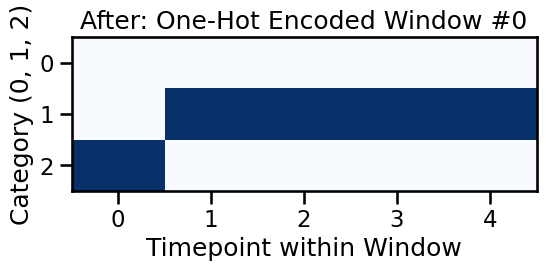

In [50]:
# --- CATEGORICAL "AFTER" PLOT ---
# The processed data is shape (windows, channels, features)
# Extract the first window, first channel: shape (15,)
processed_window = processed_cat_data[0, 0, :].numpy() 

# Reshape from flattened (15,) back to (timepoints=5, categories=3), then transpose for plotting
reshaped_window = processed_window.reshape(-1, 3).T 

fig, ax = plt.subplots(figsize=(6, 2))
ax.imshow(reshaped_window, aspect='auto', cmap='Blues', interpolation='nearest')
ax.set_title("After: One-Hot Encoded Window #0")
ax.set_xlabel("Timepoint within Window")
ax.set_ylabel("Category (0, 1, 2)")
ax.set_yticks([0, 1, 2])
plt.show()

## 5. The Alignment (`create_dataset`)

What if you want to relate continuous LFP data to spike trains? They exist in completely different mathematical formats and likely have different sampling rates. 

`NeuralMI` handles this automatically. The `create_dataset` factory processes each data stream independently based on its physics, and then safely truncates them to ensure they have the exact same number of non-overlapping windows.

In [51]:
# 1. Generate X on a strict time scale (10 seconds, sampled at 100Hz = 1000 points)
x_time = np.linspace(0, 10.0, 1000)
x_cont_raw = np.random.randn(1000, 2) 

# 2. Generate Y (Spikes), intentionally cut short to 8 seconds
y_spike_raw, _ = nmi.generators.generate_correlated_spike_trains(n_neurons=5, duration=8.0) 

# 3. Create a unified dataset with a SHARED temporal window (1.0 second)
dataset = nmi.data.handler.create_dataset(
    x_data=x_cont_raw, x_time=x_time,
    y_data=y_spike_raw,
    processor_type_x='continuous', 
    processor_type_y='spike', 
    processor_params_x={'window_size': 1.0} # A single, shared 1.0 second window!
)

print("--- Theoretical vs. Actual Sample Counts ---")
print("Continuous spans 10.0s -> 10 windows expected.")
print("Spike spans 8.0s -> 8 windows expected.")
print("\nThe library automatically aligns to the smaller, valid count:\n")
print(f"X (Continuous) shape: {dataset.x_data.shape}")
print(f"Y (Spike) shape:      {dataset.y_data.shape}")

2026-02-24 12:39:02 - neural_mi - INFO - Window coverage: 8/8 windows have sufficient data
2026-02-24 12:39:02 - neural_mi - INFO - Created 8 aligned windows
--- Theoretical vs. Actual Sample Counts ---
Continuous spans 10.0s -> 10 windows expected.
Spike spans 8.0s -> 8 windows expected.

The library automatically aligns to the smaller, valid count:

X (Continuous) shape: torch.Size([8, 2, 101])
Y (Spike) shape:      torch.Size([8, 5, 12])


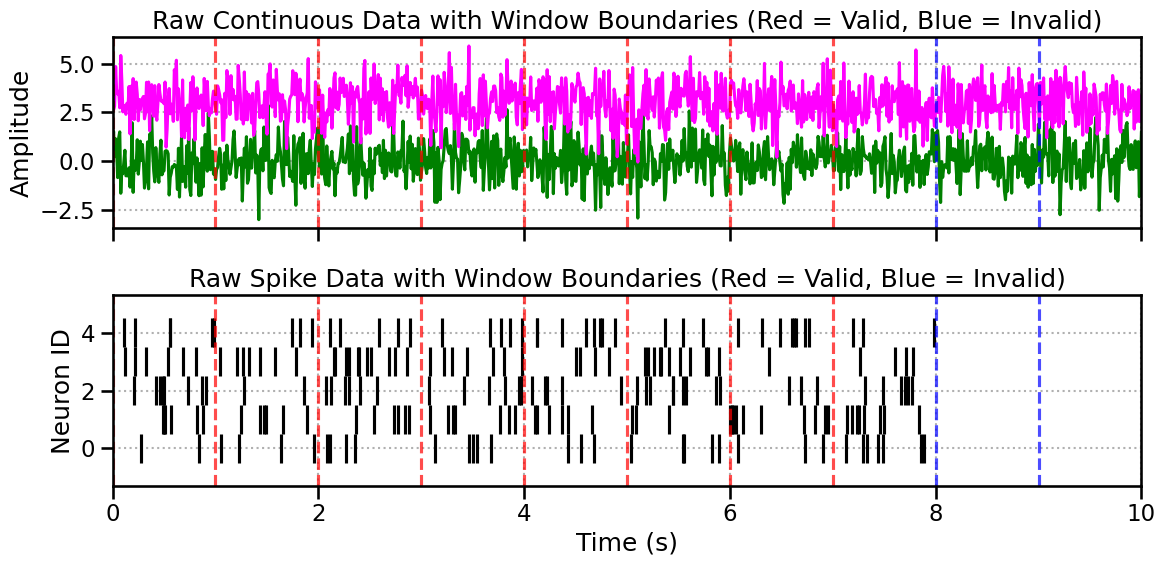

In [63]:
# Plot x_cont_raw and y_spike_raw with vertical lines indicating the 1.0s windows, second dimension of x is plotted with an offset for visibility
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(x_time, x_cont_raw[:,0], color='green')
ax[0].plot(x_time, x_cont_raw[:,1]+3, color='magenta')  # Offset the second channel for visibility
for i in range(10):
    ax[0].axvline(i, color='red' if i < 8 else 'blue', linestyle='--', alpha=0.7)
ax[0].set_title("Raw Continuous Data with Window Boundaries (Red = Valid, Blue = Invalid)")
ax[0].set_ylabel("Amplitude")
ax[0].grid(True, linestyle=':')
for i, neuron_spikes in enumerate(y_spike_raw):
    ax[1].eventplot(neuron_spikes, lineoffsets=i, colors='black')
for i in range(10):
    ax[1].axvline(i, color='red' if i < 8 else 'blue', linestyle='--', alpha=0.7)
ax[1].set_title("Raw Spike Data with Window Boundaries (Red = Valid, Blue = Invalid)")
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Neuron ID")
ax[1].set_xlim(0, 10)
ax[1].grid(True, linestyle=':')
plt.tight_layout()
plt.show()

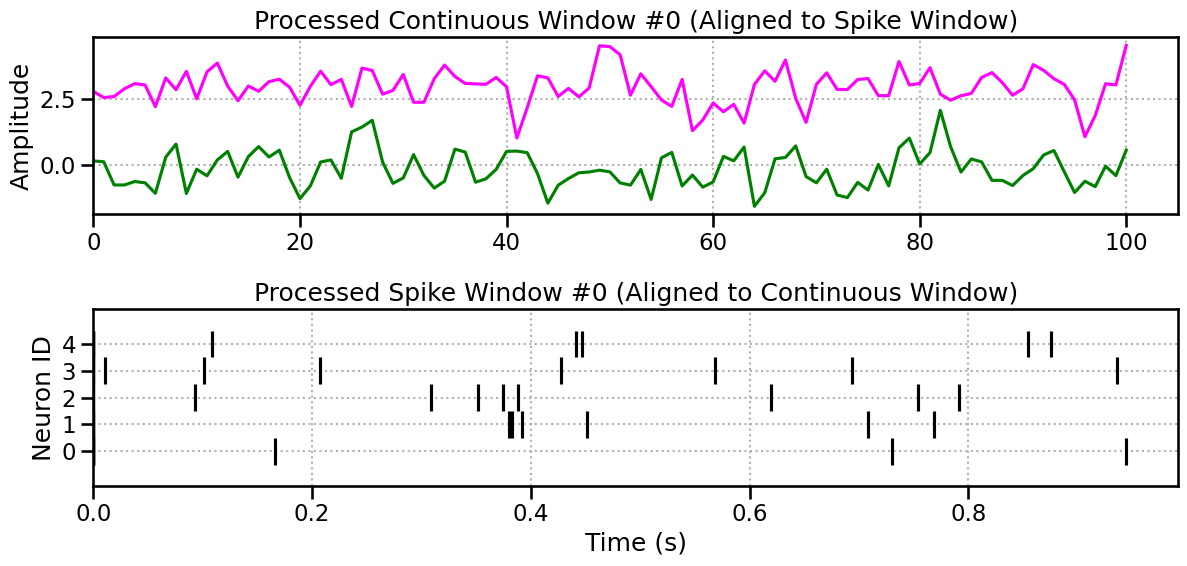

In [82]:
# Now use dataset to plot the actual windows that were created, confirming the alignment, plot the first window of x and y to confirm they match the expected time ranges.
window_to_show = 0  # The first window (0s to 1s)
fig, ax = plt.subplots(2, 1, figsize=(12, 6))

x_window_1 = dataset.x_data[window_to_show, 0, :].to('cpu').numpy()
x_window_2 = dataset.x_data[window_to_show, 1, :].to('cpu').numpy() + 3  # Offset for visibility 
y_window = dataset.y_data[window_to_show, :, :].to('cpu').numpy() 
ax[0].plot(x_window_1, color='green')
ax[0].plot(x_window_2, color='magenta')
for i, neuron_spikes in enumerate(y_window):
    ax[1].eventplot(neuron_spikes, lineoffsets=i, colors='black')
ax[0].set_title(f"Processed Continuous Window #{window_to_show} (Aligned to Spike Window)")
ax[0].set_ylabel("Amplitude")
ax[0].grid(True, linestyle=':')
ax[0].set_xlim(0)
ax[1].set_title(f"Processed Spike Window #{window_to_show} (Aligned to Continuous Window)")
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Neuron ID")
ax[1].set_yticks(range(len(y_window)))
ax[1].grid(True, linestyle=':')
ax[1].set_xlim(0)
plt.tight_layout()
plt.show()


## 6. Conclusion

You now have an intuition for how `NeuralMI` handles time.

- **Non-Overlapping Blocks:** Save memory and speed up computation.
- **Dynamic Jittering:** (Handled internally during training) Shifts these blocks randomly each epoch to learn shift-invariant features.
- **Data Processors:** Transform raw physics (voltages, discrete spikes, states) into standardized 3D tensors `(windows, channels, features)`.
- **Alignment:** Handled effortlessly by `create_dataset`.

With this foundation, you are ready for the next tutorial, where we'll learn how to use `mode='sweep'` and `mode='lag'` to search through time dynamically!